In [10]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from xgboost import XGBClassifier

In [11]:
data = load_breast_cancer()

X = data.data
y = data.target

print(X.shape)
print(y.shape)
print(data.feature_names)
print(data.target_names)

(569, 30)
(569,)
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
['malignant' 'benign']


In [12]:
df = pd.DataFrame(X, columns=data.feature_names)
df["target"] = y

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [13]:
df.shape

(569, 31)

In [14]:
df["target"].value_counts()

target
1    357
0    212
Name: count, dtype: int64

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("训练集：", X_train.shape)
print("测试集：", X_test.shape)

训练集： (455, 30)
测试集： (114, 30)


In [16]:
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [17]:
y_pred = xgb_model.predict(X_test)

print("真实结果：", y_test[:20])
print("预测结果：", y_pred[:20])

真实结果： [0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 1 1 1 1]
预测结果： [0 1 0 0 0 1 1 0 0 0 1 0 1 0 0 1 1 1 1 1]


In [18]:
acc = accuracy_score(y_test, y_pred)

print("XGBoost 准确率：", acc)

XGBoost 准确率： 0.9473684210526315


In [19]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[38  4]
 [ 2 70]]


In [20]:
print(classification_report(
    y_test,
    y_pred,
    target_names=data.target_names
))

              precision    recall  f1-score   support

   malignant       0.95      0.90      0.93        42
      benign       0.95      0.97      0.96        72

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



In [21]:
y_prob = xgb_model.predict_proba(X_test)

print(y_prob[:5])

[[0.9985598  0.00144025]
 [0.00210518 0.9978948 ]
 [0.9910538  0.00894617]
 [0.7852083  0.21479172]
 [0.9988249  0.00117511]]


In [22]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=3,
    random_state=42
)

gbdt_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

In [23]:
rf_model.fit(X_train, y_train)
gbdt_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [24]:
rf_pred = rf_model.predict(X_test)
gbdt_pred = gbdt_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

In [25]:
print("随机森林准确率：", accuracy_score(y_test, rf_pred))
print("GBDT 准确率：", accuracy_score(y_test, gbdt_pred))
print("XGBoost 准确率：", accuracy_score(y_test, xgb_pred))

随机森林准确率： 0.956140350877193
GBDT 准确率： 0.956140350877193
XGBoost 准确率： 0.9473684210526315


In [26]:
feature_importance = pd.DataFrame({
    "feature": data.feature_names,
    "importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance.head(10)

,feature,importance
20,worst radius,0.341055
22,worst perimeter,0.291130
27,worst concave points,0.066632
7,mean concave points,0.064459
11,texture error,0.036935
21,worst texture,0.020786
3,mean area,0.017436
23,worst area,0.017021
1,mean texture,0.015224
24,worst smoothness,0.013921


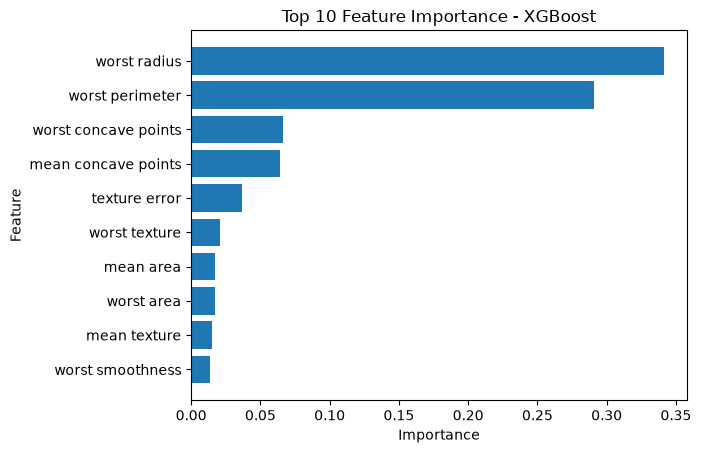

In [27]:
top_features = feature_importance.head(10)

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance - XGBoost")
plt.gca().invert_yaxis()
plt.show()

In [28]:
n_values = [10, 50, 100, 200, 300]
accuracies = []

for n in n_values:
    model = XGBClassifier(
        n_estimators=n,
        learning_rate=0.1,
        max_depth=3,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    accuracies.append(acc)

    print(f"n_estimators={n}, 准确率={acc:.4f}")

n_estimators=10, 准确率=0.9561
n_estimators=50, 准确率=0.9386
n_estimators=100, 准确率=0.9474
n_estimators=200, 准确率=0.9474
n_estimators=300, 准确率=0.9561


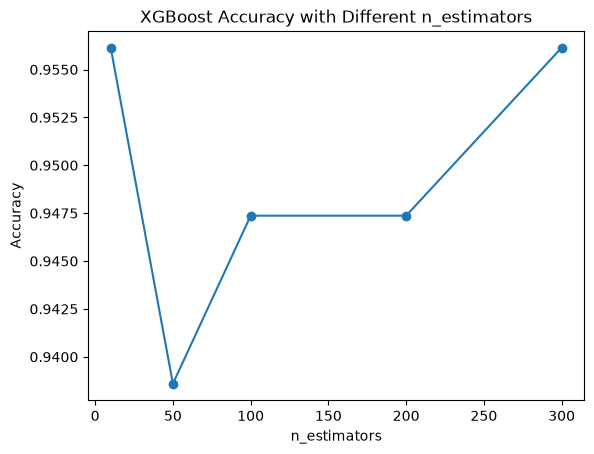

In [29]:
plt.plot(n_values, accuracies, marker="o")
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.title("XGBoost Accuracy with Different n_estimators")
plt.show()

In [30]:
lr_values = [0.01, 0.05, 0.1, 0.2, 0.5]
accuracies = []

for lr in lr_values:
    model = XGBClassifier(
        n_estimators=100,
        learning_rate=lr,
        max_depth=3,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    accuracies.append(acc)

    print(f"learning_rate={lr}, 准确率={acc:.4f}")

learning_rate=0.01, 准确率=0.9561
learning_rate=0.05, 准确率=0.9474
learning_rate=0.1, 准确率=0.9474
learning_rate=0.2, 准确率=0.9474
learning_rate=0.5, 准确率=0.9649


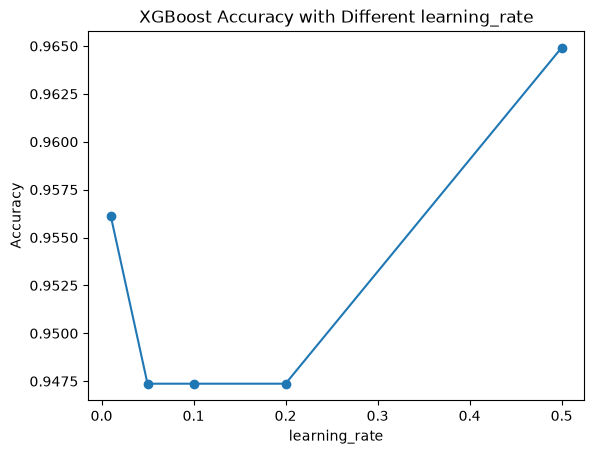

In [31]:
plt.plot(lr_values, accuracies, marker="o")
plt.xlabel("learning_rate")
plt.ylabel("Accuracy")
plt.title("XGBoost Accuracy with Different learning_rate")
plt.show()

In [32]:
depth_values = [1, 2, 3, 4, 5, 6]
accuracies = []

for depth in depth_values:
    model = XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=depth,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    accuracies.append(acc)

    print(f"max_depth={depth}, 准确率={acc:.4f}")

max_depth=1, 准确率=0.9561
max_depth=2, 准确率=0.9649
max_depth=3, 准确率=0.9474
max_depth=4, 准确率=0.9474
max_depth=5, 准确率=0.9474
max_depth=6, 准确率=0.9474


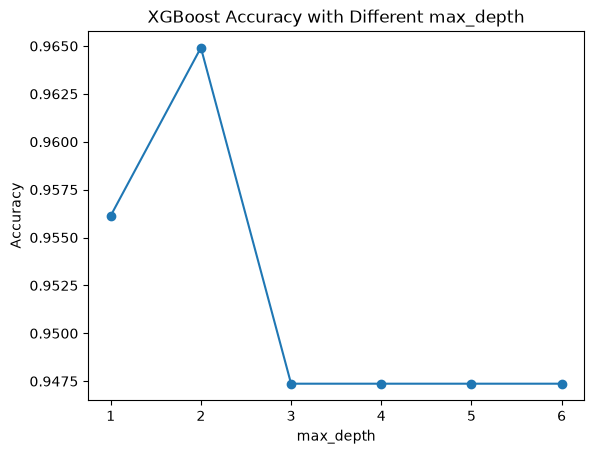

In [33]:
plt.plot(depth_values, accuracies, marker="o")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("XGBoost Accuracy with Different max_depth")
plt.show()